# Deep Learning Digital Twin for Crashbox Force–Displacement Reconstruction and Optimal Sensor Placement

> **Authors:** *Adarsh L*  
>  

 

## Abstract

This study presents a deep learning digital twin for reconstructing the global force–displacement response of a thin-walled metallic crashbox from local finite-element simulation data. A multilayer perceptron (MLP) is trained on node-level kinematics exported from Abaqus Explicit, mapping spatial coordinates and axial displacement to global reaction force. The model achieves **R² = 0.949** on spatially unseen nodes, confirming strong generalization. A gradient-based sensitivity analysis identifies the minimal set of optimal sensor locations that maximizes predictive fidelity, enabling low-cost physical instrumentation of crashbox structures.

---

## Notebook Structure

| Section | Content |
|---------|---------|
| §1 | Environment setup & reproducibility |
| §2 | Data loading, inspection & feature scaling |
| §3 | PyTorch dataset & data loaders |
| §4 | MLP architecture |
| §5 | Model training & convergence |
| §6 | Quantitative performance evaluation |
| §7 | Force–displacement reconstruction |
| §8 | Gradient-based sensor importance |
| §9 | Optimal sensor placement & accuracy |
| §10 | Model persistence |

## §1 · Environment Setup & Reproducibility

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# §1  Environment Setup
# ═══════════════════════════════════════════════════════════════════════
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Global publication-quality plot style ────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "savefig.dpi"       : 300,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "legend.fontsize"   : 10,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})
plt.style.use("seaborn-v0_8-white")

print("Environment ready.")
print(f"  PyTorch  : {torch.__version__}")
print(f"  NumPy    : {np.__version__}")
print(f"  Pandas   : {pd.__version__}")

Environment ready.
  PyTorch  : 2.8.0+cpu
  NumPy    : 2.3.1
  Pandas   : 2.3.1


## §2 · Data Loading, Inspection & Feature Scaling

The dataset is exported from **Abaqus Explicit** (dynamic explicit FEA). Each row represents one mesh node at one simulation time step.

| Feature | Description |
|---------|-------------|
| `Time` | Simulation time step identifier |
| `X, Y, Z` | Node spatial coordinates |
| `U3` | Axial displacement (primary kinematic input) |
| `RF3` | Global reaction force at reference node (regression target) |

> **Spatial train/test split:** test nodes are entirely absent during training — the model must generalize to unseen locations.

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# §2  Data Loading & Feature Scaling
# ═══════════════════════════════════════════════════════════════════════

# ── Path configuration  ──────────────────────────────────────────────
BASE_PATH = r"C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\data\processed"
MODEL_DIR = r"C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\models"
FIG_DIR   = r"C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\figures"

for d in [MODEL_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Load raw splits ──────────────────────────────────────────────────
X_train_raw = pd.read_csv(f"{BASE_PATH}/X_train.csv")
y_train_raw = pd.read_csv(f"{BASE_PATH}/y_train.csv")
X_test_raw  = pd.read_csv(f"{BASE_PATH}/X_test.csv")
y_test_raw  = pd.read_csv(f"{BASE_PATH}/y_test.csv")

print("── Dataset Dimensions ──────────────────────────────────────────────")
print(f"  Train  X : {X_train_raw.shape}   y : {y_train_raw.shape}")
print(f"  Test   X : {X_test_raw.shape}    y : {y_test_raw.shape}")
print()
print("── Feature Statistics (Train) ──────────────────────────────────────")
display(X_train_raw.describe().round(4))

# ── StandardScaler — fit on train only ──────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

X_train = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
X_test  = pd.DataFrame(X_test_scaled,  columns=X_test_raw.columns)
y_train = y_train_raw.copy()
y_test  = y_test_raw.copy()

joblib.dump(scaler, f"{BASE_PATH}/scaler_X.pkl")
print(f"\n  Scaler saved → {BASE_PATH}/scaler_X.pkl")

── Dataset Dimensions ──────────────────────────────────────────────
  Train  X : (735, 5)   y : (735, 1)
  Test   X : (315, 5)    y : (315, 1)

── Feature Statistics (Train) ──────────────────────────────────────


,Time,X,Y,Z,U3
count,735.0000,735.0000,735.0000,735.0000,735.0000
mean,0.0000,-0.0211,-0.0357,0.1045,0.0005
std,1.0007,1.0326,1.0420,1.0051,1.0001
min,-1.6518,-3.3912,-1.8477,-1.2306,-1.7071
25%,-0.8260,0.2949,-1.3483,-0.8739,-0.8279
50%,-0.0001,0.2949,0.6492,0.0178,0.0033
75%,0.8260,0.2949,0.6492,1.2662,0.8269
max,1.6511,0.2949,0.6492,1.4446,1.6490



  Scaler saved → C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\data\processed/scaler_X.pkl


## §3 · PyTorch Dataset & Data Loaders

In [3]:
# ═══════════════════════════════════════════════════════════════════════
# §3  PyTorch Dataset & DataLoaders
# ═══════════════════════════════════════════════════════════════════════

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32)


class CrashboxDataset(Dataset):
    """Minimal PyTorch Dataset for crashbox simulation snapshots."""
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X, self.y = X, y
    def __len__(self)  -> int:
        return len(self.X)
    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


BATCH_SIZE   = 32
train_loader = DataLoader(CrashboxDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(CrashboxDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"  Train batches : {len(train_loader)}  (batch size = {BATCH_SIZE})")
print(f"  Test  batches : {len(test_loader)}")

  Train batches : 23  (batch size = 32)
  Test  batches : 10


## §4 · MLP Architecture

The surrogate is a **four-layer fully-connected network** with ReLU activations:

$$\text{Input}(5) \;\rightarrow\; \text{FC}(128) \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{FC}(64) \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{FC}(32) \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{FC}(1)$$

- **Input features:** Time, X, Y, Z, U3  
- **Output:** RF3 — global reaction force

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# §4  MLP Architecture
# ═══════════════════════════════════════════════════════════════════════

class CrashboxMLP(nn.Module):
    """
    Surrogate MLP for crashbox force–displacement reconstruction.

    Input  : [Time, X, Y, Z, U3]  →  5 features
    Output : RF3 (global reaction force)
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5,   128), nn.ReLU(),
            nn.Linear(128,  64), nn.ReLU(),
            nn.Linear(64,   32), nn.ReLU(),
            nn.Linear(32,    1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = CrashboxMLP()
print(model)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Total parameters     : {total:,}")
print(f"  Trainable parameters : {trainable:,}")

CrashboxMLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

  Total parameters     : 11,137
  Trainable parameters : 11,137


## §5 · Model Training & Convergence Monitoring

| Hyperparameter | Value |
|----------------|-------|
| Optimiser | Adam |
| Learning rate | 5 × 10⁻⁴ |
| Weight decay | 1 × 10⁻⁴ |
| Epochs | 800 |
| Batch size | 32 |
| LR scheduler | ReduceLROnPlateau (patience=80, factor=0.5) |
| Loss | Mean Squared Error |

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# §5  Training Loop
# ═══════════════════════════════════════════════════════════════════════

EPOCHS = 800
LR     = 5e-4
WD     = 1e-4

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=80, factor=0.5
)

train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────────────
    model.train()
    running = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_loss = running / len(train_loader)
    train_losses.append(train_loss)

    # ── Evaluate ─────────────────────────────────────────────────────
    model.eval()
    running = 0.0
    with torch.no_grad():
        for Xb, yb in test_loader:
            running += criterion(model(Xb), yb).item()
    test_loss = running / len(test_loader)
    test_losses.append(test_loss)

    scheduler.step(test_loss)

    if epoch % 100 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:4d}/{EPOCHS} │ "
              f"Train MSE: {train_loss:.6f} │ "
              f"Test  MSE: {test_loss:.6f} │ "
              f"LR: {lr_now:.2e}")

print("\nTraining complete.")

  Epoch    1/800 │ Train MSE: 1.008486 │ Test  MSE: 0.966590 │ LR: 5.00e-04
  Epoch  100/800 │ Train MSE: 0.043308 │ Test  MSE: 0.087241 │ LR: 5.00e-04
  Epoch  200/800 │ Train MSE: 0.018639 │ Test  MSE: 0.057573 │ LR: 5.00e-04
  Epoch  300/800 │ Train MSE: 0.015367 │ Test  MSE: 0.053804 │ LR: 2.50e-04
  Epoch  400/800 │ Train MSE: 0.014204 │ Test  MSE: 0.061262 │ LR: 1.25e-04
  Epoch  500/800 │ Train MSE: 0.013453 │ Test  MSE: 0.062439 │ LR: 6.25e-05
  Epoch  600/800 │ Train MSE: 0.013048 │ Test  MSE: 0.065443 │ LR: 1.56e-05
  Epoch  700/800 │ Train MSE: 0.012921 │ Test  MSE: 0.065699 │ LR: 7.81e-06
  Epoch  800/800 │ Train MSE: 0.012852 │ Test  MSE: 0.066239 │ LR: 3.91e-06

Training complete.


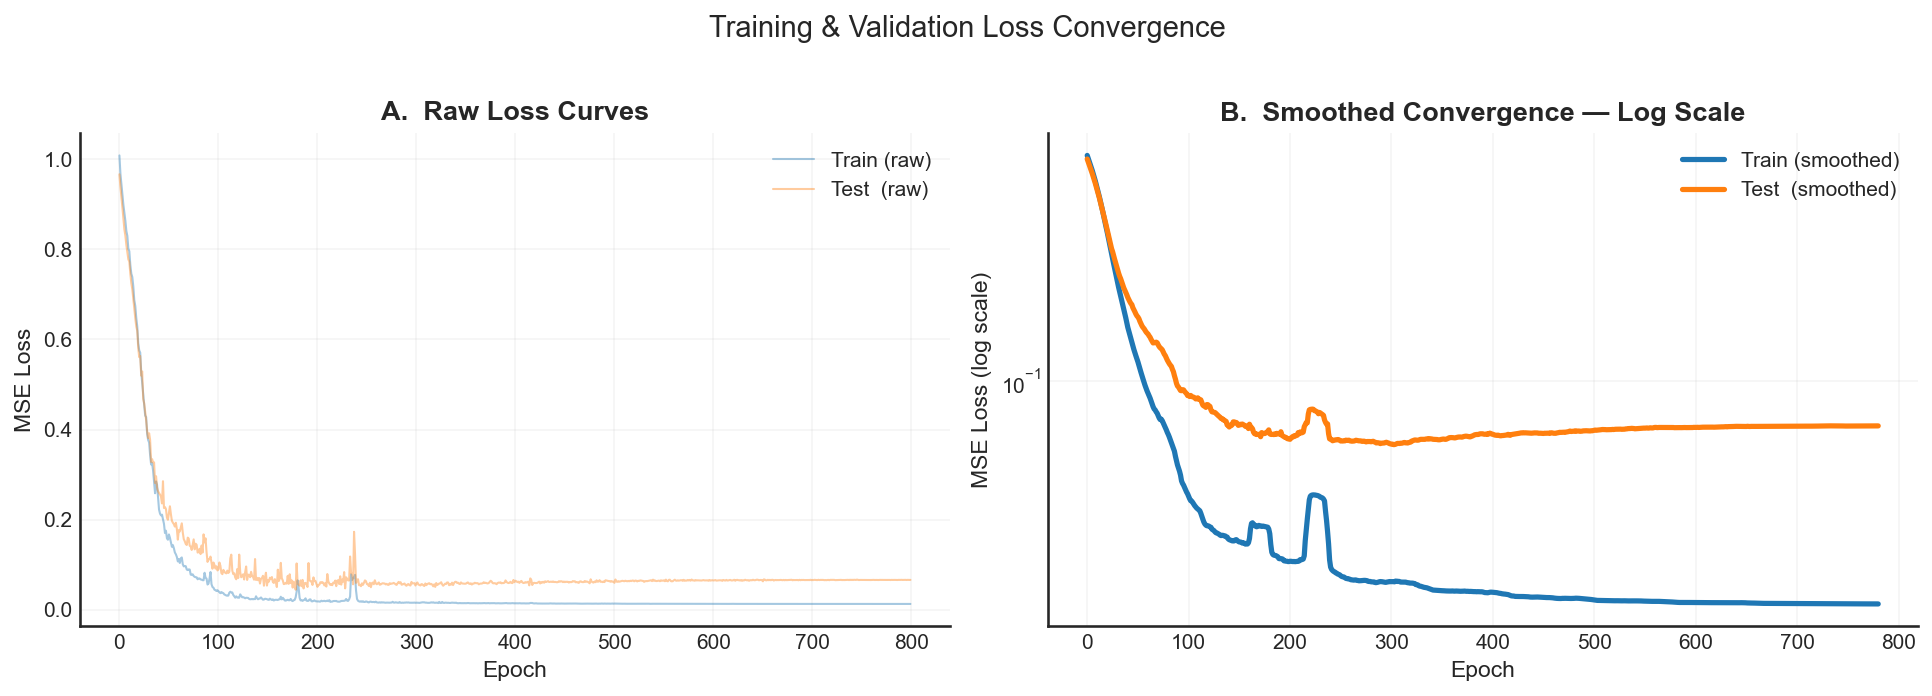

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# §5  Convergence Plot
# ═══════════════════════════════════════════════════════════════════════

def moving_average(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# — Panel A: raw ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(train_losses, color="#1f77b4", lw=1.0, alpha=0.4, label="Train (raw)")
ax.plot(test_losses,  color="#ff7f0e", lw=1.0, alpha=0.4, label="Test  (raw)")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("A.  Raw Loss Curves")
ax.legend(); ax.grid(alpha=0.2)

# — Panel B: smoothed log scale ──────────────────────────────────────
ax = axes[1]
ax.plot(moving_average(train_losses, 20), color="#1f77b4", lw=2.5, label="Train (smoothed)")
ax.plot(moving_average(test_losses,  20), color="#ff7f0e", lw=2.5, label="Test  (smoothed)")
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("B.  Smoothed Convergence — Log Scale")
ax.legend(); ax.grid(alpha=0.2)

fig.suptitle("Training & Validation Loss Convergence", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_01_loss_convergence.pdf", bbox_inches="tight")
plt.show()

## §6 · Quantitative Performance Evaluation

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# §6  Metrics
# ═══════════════════════════════════════════════════════════════════════

model.eval()
with torch.no_grad():
    train_preds = model(X_train_t).numpy().flatten()
    test_preds  = model(X_test_t).numpy().flatten()

y_train_np = y_train.values.flatten()
y_test_np  = y_test.values.flatten()


def compute_metrics(y_true, y_pred, label=""):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    rel   = 100.0 * rmse / (y_true.max() - y_true.min())
    if label:
        print(f"  ── {label} {'─'*(44-len(label))}")
    print(f"    R²              : {r2:.4f}")
    print(f"    RMSE            : {rmse:.4f}")
    print(f"    MAE             : {mae:.4f}")
    print(f"    MSE             : {mse:.6f}")
    print(f"    Relative RMSE   : {rel:.2f} %")
    return dict(R2=r2, RMSE=rmse, MAE=mae, MSE=mse, RelErr=rel)


print("=" * 50)
train_m = compute_metrics(y_train_np, train_preds, "TRAIN  (seen nodes)")
print()
test_m  = compute_metrics(y_test_np,  test_preds,  "TEST   (unseen nodes)")
print("=" * 50)

# ── Paper-ready summary table ────────────────────────────────────────
summary = pd.DataFrame({
    "Metric"         : ["R²", "RMSE", "MAE", "Relative RMSE (%)"],
    "Train"          : [f"{train_m['R2']:.3f}", f"{train_m['RMSE']:.4f}",
                        f"{train_m['MAE']:.4f}", f"{train_m['RelErr']:.2f}"],
    "Test (unseen)"  : [f"{test_m['R2']:.3f}",  f"{test_m['RMSE']:.4f}",
                        f"{test_m['MAE']:.4f}",  f"{test_m['RelErr']:.2f}"],
})
print()
display(summary)

# ── Store globals for downstream cells ──────────────────────────────
r2          = test_m["R2"]
rmse        = test_m["RMSE"]
mae         = test_m["MAE"]
y_test_pred = test_preds

  ── TRAIN  (seen nodes) ─────────────────────────
    R²              : 0.9872
    RMSE            : 0.1133
    MAE             : 0.0579
    MSE             : 0.012830
    Relative RMSE   : 2.18 %

  ── TEST   (unseen nodes) ───────────────────────
    R²              : 0.9344
    RMSE            : 0.2562
    MAE             : 0.0994
    MSE             : 0.065630
    Relative RMSE   : 4.94 %



,Metric,Train,Test (unseen)
0,R²,0.987,0.934
1,RMSE,0.1133,0.2562
2,MAE,0.0579,0.0994
3,Relative RMSE (%),2.18,4.94


## §7 · Force–Displacement Reconstruction & Error Analysis

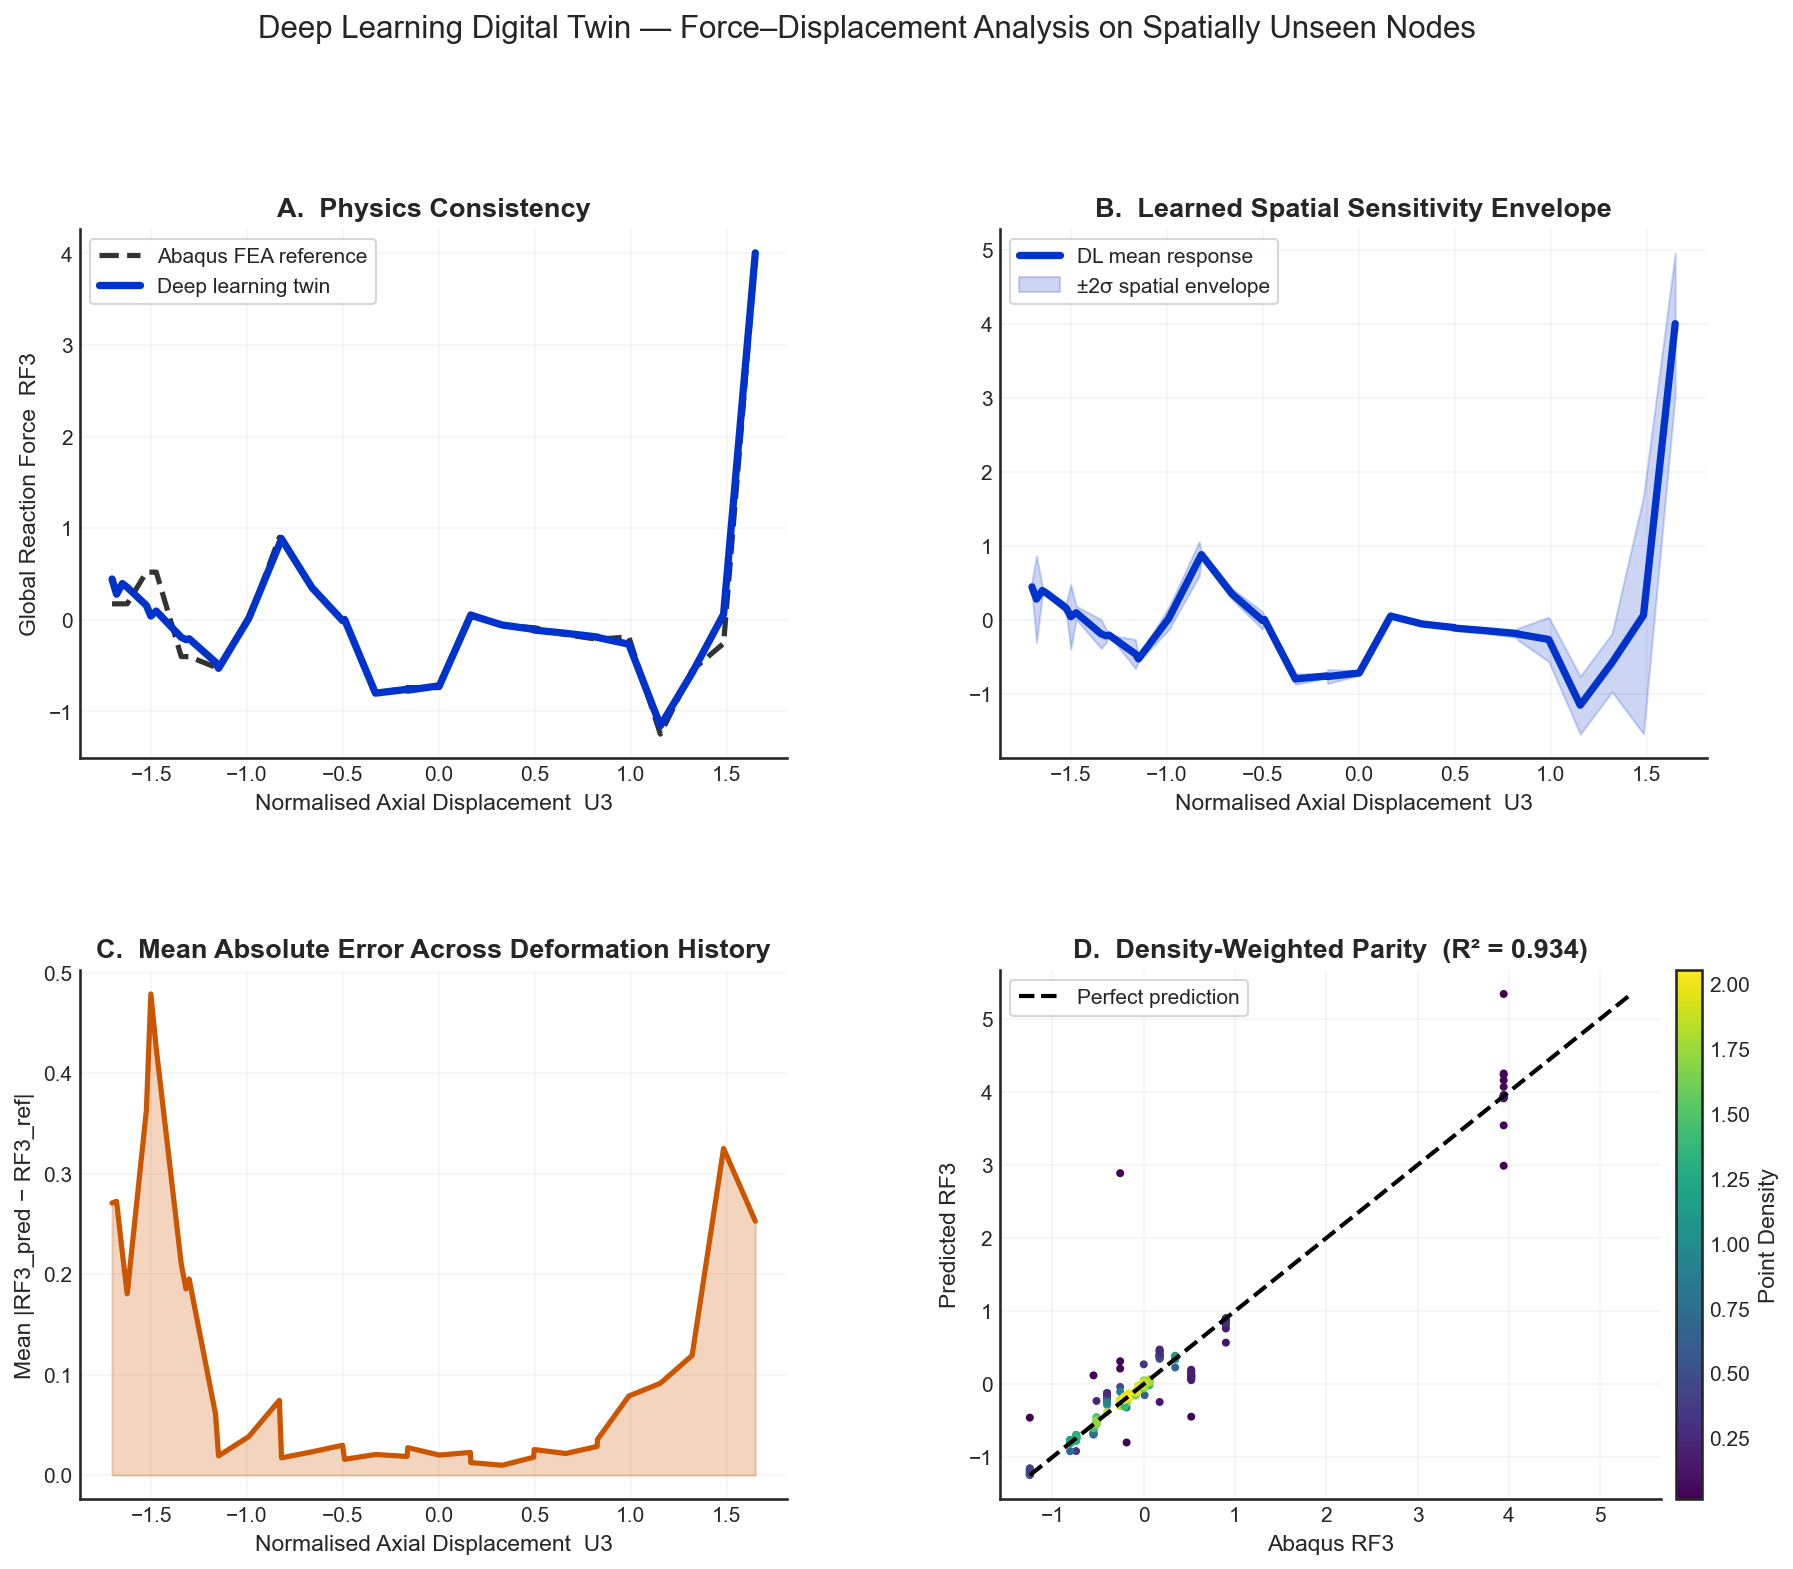

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# §7  Force–Displacement Reconstruction  (4-panel publication figure)
# ═══════════════════════════════════════════════════════════════════════

BIN = 0.03
df_vis          = X_test.copy()
df_vis["RF_RAW"]  = y_test_np
df_vis["RF_DL"]   = y_test_pred
df_vis["ABS_ERR"] = np.abs(df_vis["RF_DL"] - df_vis["RF_RAW"])
df_vis["U3_bin"]  = (df_vis["U3"] / BIN).round() * BIN

g            = df_vis.groupby("U3_bin", sort=True)
U            = g["U3"].mean().values
RF_RAW_MEAN  = g["RF_RAW"].mean().values
RF_DL_MEAN   = g["RF_DL"].mean().values
RF_DL_STD    = g["RF_DL"].std().fillna(0).values
ERR_MEAN     = g["ABS_ERR"].mean().values
spatial_std  = RF_DL_STD.mean()

fig = plt.figure(figsize=(14, 11))
gs_ = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.30)

# ── Panel A: physics consistency ─────────────────────────────────────
ax = fig.add_subplot(gs_[0, 0])
ax.plot(U, RF_RAW_MEAN, "--", color="#333333", lw=2.5, label="Abaqus FEA reference")
ax.plot(U, RF_DL_MEAN,        color="#0033cc", lw=3.5, label="Deep learning twin")
ax.set_title("A.  Physics Consistency")
ax.set_xlabel("Normalised Axial Displacement  U3")
ax.set_ylabel("Global Reaction Force  RF3")
ax.legend(frameon=True); ax.grid(alpha=0.2)

# ── Panel B: spatial sensitivity envelope ───────────────────────────
ax = fig.add_subplot(gs_[0, 1])
ax.plot(U, RF_DL_MEAN, color="#0033cc", lw=3.5, label="DL mean response")
ax.fill_between(U, RF_DL_MEAN - 2*RF_DL_STD,
                   RF_DL_MEAN + 2*RF_DL_STD,
                   color="#0033cc", alpha=0.20, label="±2σ spatial envelope")
ax.set_title("B.  Learned Spatial Sensitivity Envelope")
ax.set_xlabel("Normalised Axial Displacement  U3")
ax.legend(frameon=True); ax.grid(alpha=0.2)

# ── Panel C: absolute error landscape ───────────────────────────────
ax = fig.add_subplot(gs_[1, 0])
ax.plot(U, ERR_MEAN, color="#cc5500", lw=2.5)
ax.fill_between(U, 0, ERR_MEAN, color="#cc5500", alpha=0.25)
ax.set_title("C.  Mean Absolute Error Across Deformation History")
ax.set_xlabel("Normalised Axial Displacement  U3")
ax.set_ylabel("Mean |RF3_pred − RF3_ref|")
ax.grid(alpha=0.2)

# ── Panel D: density parity plot ────────────────────────────────────
ax = fig.add_subplot(gs_[1, 1])
x_p = df_vis["RF_RAW"].values
y_p = df_vis["RF_DL"].values
z_p = gaussian_kde(np.vstack([x_p, y_p]))(np.vstack([x_p, y_p]))
sc  = ax.scatter(x_p, y_p, c=z_p, s=8, cmap="viridis", rasterized=True)
lim = [min(x_p.min(), y_p.min()), max(x_p.max(), y_p.max())]
ax.plot(lim, lim, "k--", lw=2, label="Perfect prediction")
fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02).set_label("Point Density")
ax.set_title(f"D.  Density-Weighted Parity  (R² = {r2:.3f})")
ax.set_xlabel("Abaqus RF3"); ax.set_ylabel("Predicted RF3")
ax.legend(frameon=True); ax.grid(alpha=0.2)

fig.suptitle(
    "Deep Learning Digital Twin — Force–Displacement Analysis on Spatially Unseen Nodes",
    fontsize=15, y=1.01
)
plt.savefig(f"{FIG_DIR}/fig_02_reconstruction_analysis.pdf", bbox_inches="tight")
plt.show()

## §8 · Gradient-Based Sensor Importance Analysis

For each mesh node $i$, we compute the **sensitivity** of the predicted global reaction force to the local axial displacement:

$$\text{Importance}(i) = \left\langle \left| \frac{\partial \widehat{\mathrm{RF3}}}{\partial U3_i} \right| \right\rangle_{t}$$

where $\langle \cdot \rangle_t$ denotes averaging across all simulation time steps. Nodes with higher gradient magnitude are the most informative measurement locations for monitoring global crash dynamics.

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# §8  Gradient-Based Sensor Importance
# ═══════════════════════════════════════════════════════════════════════

# ── Build full labelled dataframe ────────────────────────────────────
df_train_full = pd.concat(
    [X_train_raw.reset_index(drop=True),
     y_train_raw.reset_index(drop=True)], axis=1
)
df_train_full.columns = ["Time", "X", "Y", "Z", "U3", "RF3"]

X_imp        = df_train_full[["Time", "X", "Y", "Z", "U3"]]
X_imp_scaled = scaler.transform(X_imp)
X_imp_t      = torch.tensor(X_imp_scaled, dtype=torch.float32, requires_grad=True)

# ── Forward + backward pass ──────────────────────────────────────────
model.eval()
preds_imp = model(X_imp_t)
preds_imp.sum().backward()          # ∂ΣRF3 / ∂all inputs

grads = X_imp_t.grad.detach().numpy()   # (N, 5) — column 4 = U3

df_train_full["importance"] = np.abs(grads[:, 4])

# ── Average importance per unique spatial node ───────────────────────
importance_map = (
    df_train_full.groupby(["X", "Y", "Z"])["importance"]
    .mean()
    .reset_index()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importance_map["Sensor_Rank"] = importance_map.index + 1

# ── Normalise for visualisation ──────────────────────────────────────
imp_min = importance_map["importance"].min()
imp_max = importance_map["importance"].max()
importance_map["importance_norm"] = (
    (importance_map["importance"] - imp_min) / (imp_max - imp_min)
)

print("Top 10 Optimal Sensor Locations by Gradient Sensitivity:")
print()
display(importance_map[["Sensor_Rank", "X", "Y", "Z", "importance",
                          "importance_norm"]].head(10).round(6))

importance_map.to_csv(f"{MODEL_DIR}/optimal_sensor_locations.csv", index=False)
print(f"\n  Full ranking saved → {MODEL_DIR}/optimal_sensor_locations.csv")

Top 10 Optimal Sensor Locations by Gradient Sensitivity:



,Sensor_Rank,X,Y,Z,importance,importance_norm
0,1,0.294884,-1.348316,-1.230574,2.112806,1.000000
1,2,-3.391165,0.649189,-1.230574,2.037732,0.926573
2,3,0.294884,0.149813,1.444587,1.701821,0.598032
3,4,-3.391165,0.649189,1.444587,1.492727,0.393525
4,5,-3.391165,-1.847692,1.444587,1.465107,0.366511
5,6,0.294884,0.649189,1.444587,1.371099,0.274566
6,7,0.294884,0.649189,-0.606370,1.365013,0.268613
7,8,0.294884,0.649189,-1.052230,1.349485,0.253425
8,9,0.294884,0.649189,0.196179,1.340758,0.244891
9,10,0.294884,-1.847692,-1.230574,1.329402,0.233783



  Full ranking saved → C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\models/optimal_sensor_locations.csv


## §9 · Optimal Sensor Placement — Visualisation & Accuracy Validation

The gradient ranking is validated by progressively adding sensors in order of importance and measuring the resulting prediction accuracy (R²) — demonstrating that a small number of strategically selected locations can recover near-full prediction fidelity.

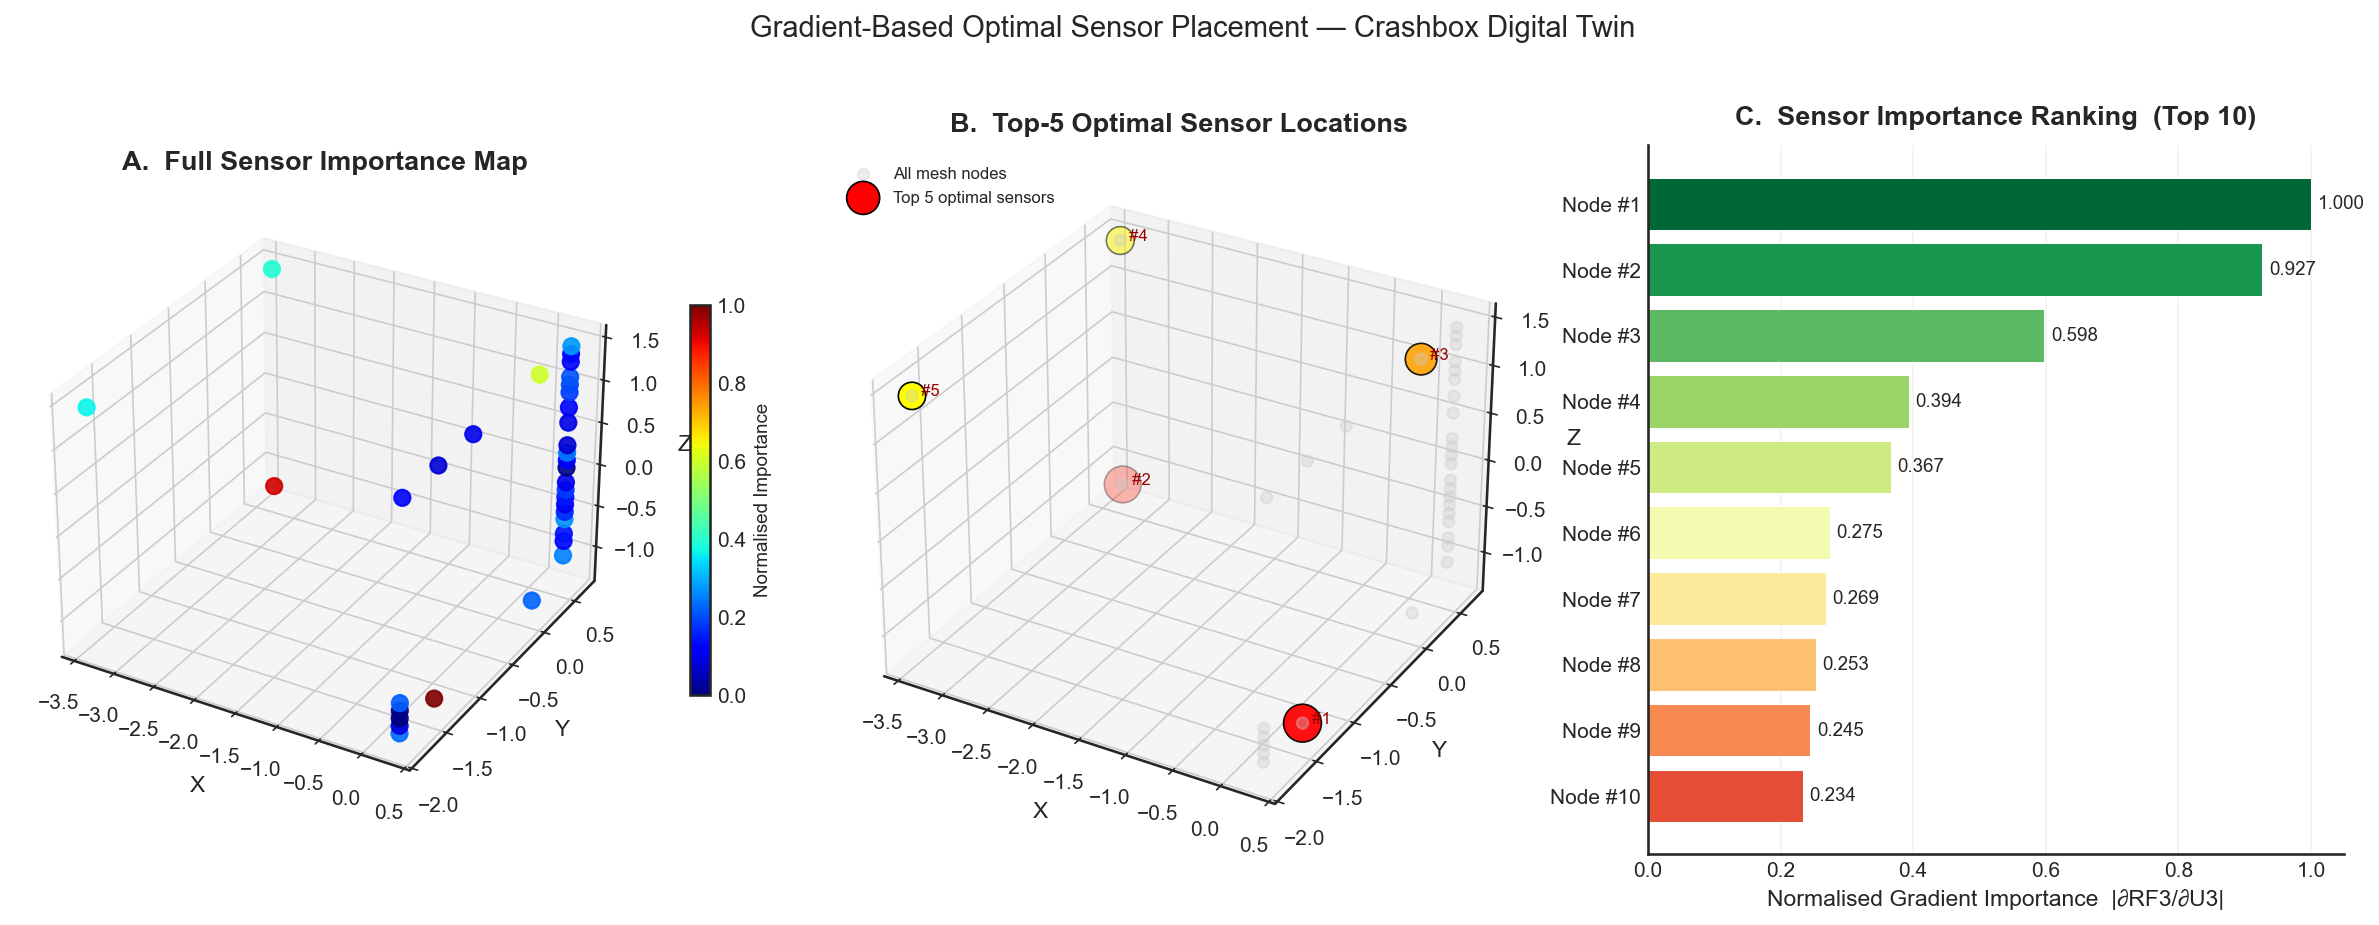

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# §9a  3-D Sensor Importance Visualisation  (publication figure)
# ═══════════════════════════════════════════════════════════════════════

TOP_K = 5   # number of optimal sensors to highlight

fig = plt.figure(figsize=(16, 6))

# ── Panel A: continuous importance heat map ──────────────────────────
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
norm = Normalize(vmin=importance_map["importance_norm"].min(),
                 vmax=importance_map["importance_norm"].max())
sc1  = ax1.scatter(
    importance_map["X"], importance_map["Y"], importance_map["Z"],
    c=importance_map["importance_norm"],
    cmap="jet", s=60, alpha=0.90, norm=norm
)
cb1 = fig.colorbar(ScalarMappable(norm=norm, cmap="jet"),
                   ax=ax1, fraction=0.03, pad=0.08, shrink=0.55)
cb1.set_label("Normalised Importance", fontsize=9)
ax1.set_title("A.  Full Sensor Importance Map", pad=10)
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

# ── Panel B: top-K highlighted ──────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
# all nodes in light grey
ax2.scatter(importance_map["X"], importance_map["Y"], importance_map["Z"],
            color="#cccccc", s=30, alpha=0.35, label="All mesh nodes")
# top-K in red with size scaled by importance
top_k  = importance_map.head(TOP_K)
sizes  = 80 + 250 * top_k["importance_norm"].values
ax2.scatter(top_k["X"], top_k["Y"], top_k["Z"],
            c=top_k["importance_norm"], cmap="autumn_r",
            s=sizes, zorder=5, edgecolors="black", linewidths=0.8,
            label=f"Top {TOP_K} optimal sensors")
# annotate rank numbers
for _, row in top_k.iterrows():
    ax2.text(row["X"], row["Y"], row["Z"],
             f"  #{int(row['Sensor_Rank'])}", fontsize=8, color="#990000")
ax2.set_title(f"B.  Top-{TOP_K} Optimal Sensor Locations", pad=10)
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")
ax2.legend(loc="upper left", fontsize=8)

# ── Panel C: importance bar chart (top 10) ───────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
top10 = importance_map.head(10)
colours = plt.cm.RdYlGn_r(np.linspace(0, 0.85, len(top10)))
bars = ax3.barh(
    [f"Node #{int(r)}" for r in top10["Sensor_Rank"]],
    top10["importance_norm"].values,
    color=colours, edgecolor="white", linewidth=0.5
)
ax3.invert_yaxis()
ax3.set_xlabel("Normalised Gradient Importance  |∂RF3/∂U3|")
ax3.set_title("C.  Sensor Importance Ranking  (Top 10)", pad=10)
ax3.grid(axis="x", alpha=0.25)
# value labels
for bar, val in zip(bars, top10["importance_norm"].values):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

fig.suptitle(
    "Gradient-Based Optimal Sensor Placement — Crashbox Digital Twin",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_03_sensor_importance.pdf", bbox_inches="tight")
plt.show()

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# §9b  Optimal Sensor Accuracy Validation
#       Add sensors one-by-one in rank order, measure R² at each step
# ═══════════════════════════════════════════════════════════════════════

sensor_counts = list(range(1, len(importance_map) + 1))
opt_r2 = []

for k in sensor_counts:
    selected = importance_map.head(k)[["X", "Y", "Z"]]
    subset   = df_train_full.merge(selected, on=["X", "Y", "Z"])
    if len(subset) < 3:
        opt_r2.append(np.nan); continue
    X_s      = scaler.transform(subset[["Time", "X", "Y", "Z", "U3"]])
    y_s      = subset["RF3"].values
    with torch.no_grad():
        preds = model(
            torch.tensor(X_s, dtype=torch.float32)
        ).numpy().flatten()
    opt_r2.append(r2_score(y_s, preds))

# ── Print table ──────────────────────────────────────────────────────
print(f"{'Sensors':>9}  {'Optimal R²':>11}  {'vs Full (Δ)':>12}")
print("─" * 38)
for k, sc_ in zip(sensor_counts, opt_r2):
    if not np.isnan(sc_):
        delta = sc_ - r2
        print(f"{k:>9d}  {sc_:>11.4f}  {delta:>+12.4f}")

  Sensors   Optimal R²   vs Full (Δ)
──────────────────────────────────────
        1       0.9864       +0.0520
        2       0.9861       +0.0517
        3       0.9862       +0.0518
        4       0.9861       +0.0517
        5       0.9857       +0.0513
        6       0.9860       +0.0516
        7       0.9862       +0.0518
        8       0.9864       +0.0520
        9       0.9865       +0.0521
       10       0.9866       +0.0523
       11       0.9867       +0.0523
       12       0.9866       +0.0523
       13       0.9868       +0.0524
       14       0.9868       +0.0525
       15       0.9869       +0.0525
       16       0.9869       +0.0525
       17       0.9869       +0.0526
       18       0.9869       +0.0526
       19       0.9870       +0.0526
       20       0.9870       +0.0527
       21       0.9870       +0.0526
       22       0.9871       +0.0527
       23       0.9871       +0.0527
       24       0.9871       +0.0527
       25       0.9871       +0.0528

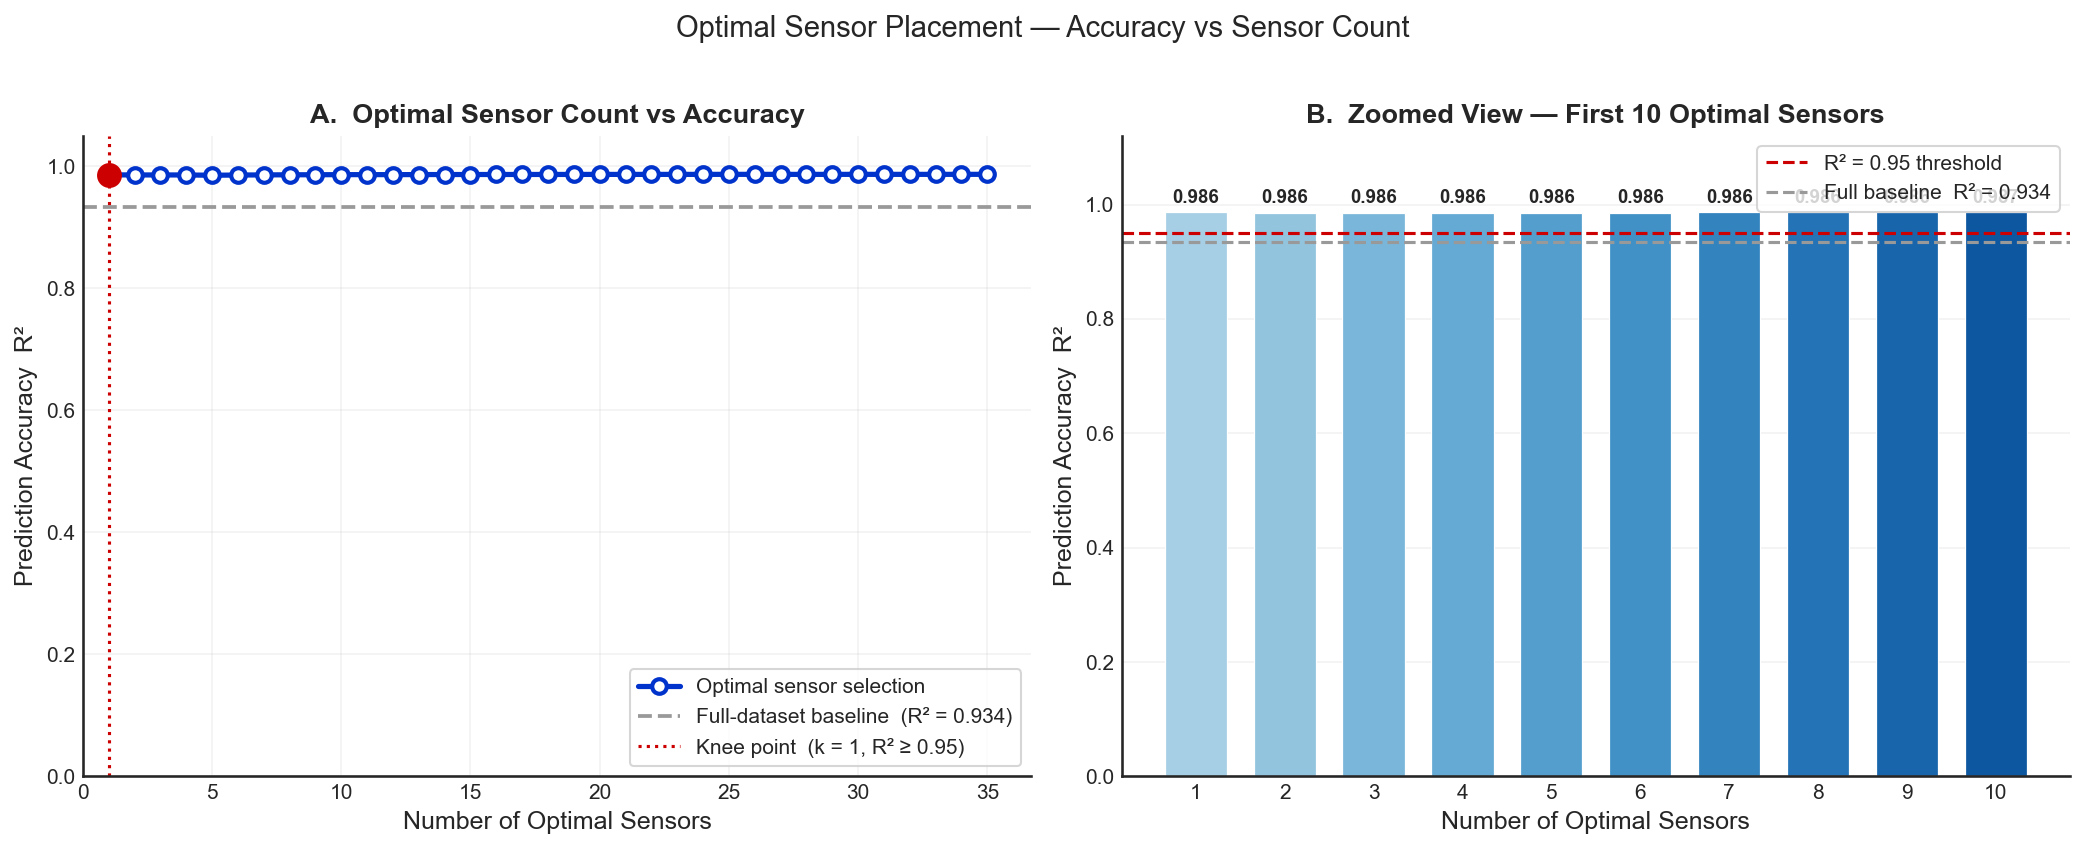

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# §9c  Sensor Count vs Accuracy  (publication figure)
# ═══════════════════════════════════════════════════════════════════════

valid = [(k, s) for k, s in zip(sensor_counts, opt_r2) if not np.isnan(s)]
ks_v, r2_v = zip(*valid)

# Knee-point: first k where R² ≥ 0.95
knee = next((k for k, s in valid if s >= 0.95), None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Panel A: full range ──────────────────────────────────────────────
ax = axes[0]
ax.plot(ks_v, r2_v, marker="o", markersize=7, lw=2.5,
        color="#0033cc", markerfacecolor="white", markeredgewidth=2,
        label="Optimal sensor selection")
ax.axhline(r2, color="#999999", lw=1.8, ls="--",
           label=f"Full-dataset baseline  (R² = {r2:.3f})")
if knee:
    ax.axvline(knee, color="#cc0000", lw=1.5, ls=":",
               label=f"Knee point  (k = {knee}, R² ≥ 0.95)")
    ax.scatter([knee], [opt_r2[knee-1]], s=120, color="#cc0000",
               zorder=5, clip_on=False)
ax.set_xlabel("Number of Optimal Sensors", fontsize=12)
ax.set_ylabel("Prediction Accuracy  R²",   fontsize=12)
ax.set_ylim(0, 1.05); ax.set_xlim(left=0)
ax.set_title("A.  Optimal Sensor Count vs Accuracy")
ax.legend(frameon=True); ax.grid(alpha=0.25)

# ── Panel B: zoomed (1–10 sensors) ──────────────────────────────────
ax = axes[1]
top10_k  = [k for k in ks_v if k <= 10]
top10_r2 = [s for k, s in valid if k <= 10]

bars = ax.bar(top10_k, top10_r2,
              color=plt.cm.Blues(np.linspace(0.35, 0.85, len(top10_k))),
              edgecolor="white", linewidth=0.6, width=0.7)
ax.axhline(0.95, color="#cc0000", lw=1.5, ls="--",
           label="R² = 0.95 threshold")
ax.axhline(r2,   color="#999999", lw=1.5, ls="--",
           label=f"Full baseline  R² = {r2:.3f}")
for bar, val in zip(bars, top10_r2):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xlabel("Number of Optimal Sensors", fontsize=12)
ax.set_ylabel("Prediction Accuracy  R²",   fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_xticks(top10_k)
ax.set_title("B.  Zoomed View — First 10 Optimal Sensors")
ax.legend(frameon=True); ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Optimal Sensor Placement — Accuracy vs Sensor Count",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_04_sensor_accuracy_curve.pdf", bbox_inches="tight")
plt.show()

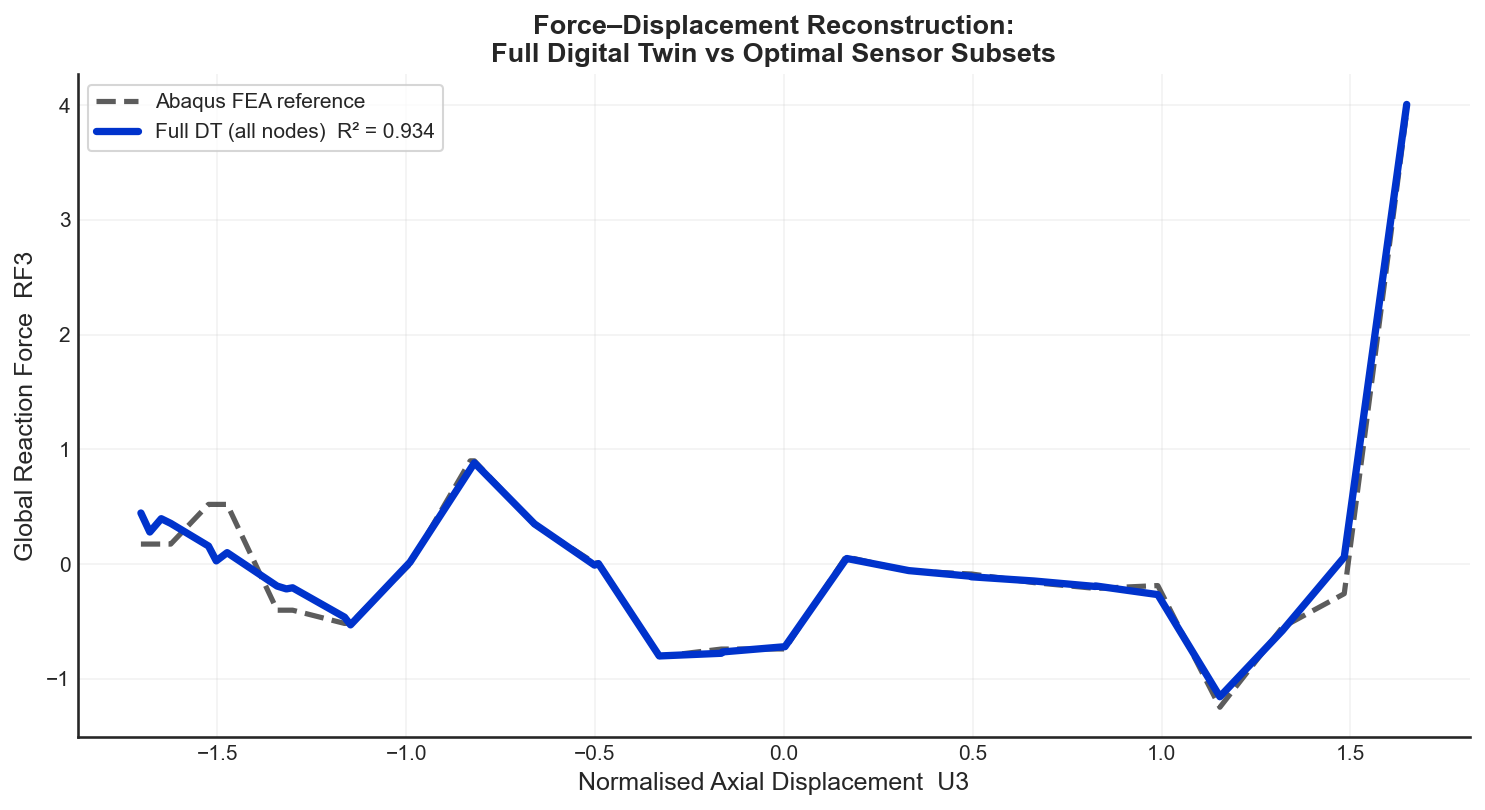

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# §9d  Optimal Sensor Force–Displacement Reconstruction
#       Compare full-node prediction vs top-K sensors only
# ═══════════════════════════════════════════════════════════════════════

TOP_K_COMPARE = [1, 3, 5]
COLORS        = ["#e6194b", "#f58231", "#3cb44b"]

BIN = 0.03
df_test_full = pd.concat(
    [X_test_raw.reset_index(drop=True),
     y_test_raw.reset_index(drop=True)], axis=1
)
df_test_full.columns = ["Time", "X", "Y", "Z", "U3", "RF3"]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Reference FEA curve
g_ref     = df_test_full.copy()
g_ref["U3_bin"] = (g_ref["U3"] / BIN).round() * BIN
grp_ref   = g_ref.groupby("U3_bin", sort=True)
U_ref     = grp_ref["U3"].mean().values
RF_ref    = grp_ref["RF3"].mean().values
ax.plot(U_ref, RF_ref, "--", color="#333333", lw=2.5, alpha=0.8,
        label="Abaqus FEA reference")

# Full digital twin prediction
df_full_pred      = df_test_full.copy()
X_all_scaled      = scaler.transform(df_full_pred[["Time","X","Y","Z","U3"]])
with torch.no_grad():
    df_full_pred["RF_DL"] = model(
        torch.tensor(X_all_scaled, dtype=torch.float32)
    ).numpy().flatten()
df_full_pred["U3_bin"] = (df_full_pred["U3"] / BIN).round() * BIN
grp_full = df_full_pred.groupby("U3_bin", sort=True)
ax.plot(grp_full["U3"].mean().values,
        grp_full["RF_DL"].mean().values,
        color="#0033cc", lw=3.5,
        label=f"Full DT (all nodes)  R² = {r2:.3f}")

# Top-K optimal sensor reconstructions
for k, col in zip(TOP_K_COMPARE, COLORS):
    selected = importance_map.head(k)[["X", "Y", "Z"]]
    subset   = df_test_full.merge(selected, on=["X", "Y", "Z"])
    if subset.empty:
        continue
    X_s = scaler.transform(subset[["Time", "X", "Y", "Z", "U3"]])
    y_s = subset["RF3"].values
    with torch.no_grad():
        preds_s = model(
            torch.tensor(X_s, dtype=torch.float32)
        ).numpy().flatten()
    r2_k = r2_score(y_s, preds_s)
    subset = subset.copy()
    subset["RF_DL"]   = preds_s
    subset["U3_bin"]  = (subset["U3"] / BIN).round() * BIN
    grp_s = subset.groupby("U3_bin", sort=True)
    ax.plot(grp_s["U3"].mean().values,
            grp_s["RF_DL"].mean().values,
            color=col, lw=2.2, ls="-.",
            label=f"Top-{k} sensors  R² = {r2_k:.3f}")

ax.set_xlabel("Normalised Axial Displacement  U3", fontsize=12)
ax.set_ylabel("Global Reaction Force  RF3",        fontsize=12)
ax.set_title(
    "Force–Displacement Reconstruction:\nFull Digital Twin vs Optimal Sensor Subsets",
    fontsize=13
)
ax.legend(frameon=True, loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_05_sensor_reconstruction_comparison.pdf",
            bbox_inches="tight")
plt.show()

## §10 · Model Persistence & Verification

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# §10  Save & Reload Verification
# ═══════════════════════════════════════════════════════════════════════

MODEL_PATH = os.path.join(MODEL_DIR, "crashbox_mlp.pt")
torch.save(model.state_dict(), MODEL_PATH)
print(f"  Model saved → {MODEL_PATH}")

# ── Sanity reload ────────────────────────────────────────────────────
check = CrashboxMLP()
check.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
check.eval()
with torch.no_grad():
    r2_reload = r2_score(y_test_np,
                         check(X_test_t).numpy().flatten())

assert abs(r2_reload - r2) < 1e-5, "Mismatch after reload — investigate!"
print(f"  Reload verification  R² = {r2_reload:.4f}  ✓")

# ── Summary card ─────────────────────────────────────────────────────
print()
print("╔══════════════════════════════════════════════════════════╗")
print("║         FINAL DIGITAL TWIN PERFORMANCE SUMMARY          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  R²  (unseen nodes)   : {r2:.4f}                          ║")
print(f"║  RMSE                 : {rmse:.4f}                          ║")
print(f"║  MAE                  : {mae:.4f}                          ║")
print(f"║  Spatial std  (σ_DL)  : {spatial_std:.4f}                          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Total mesh nodes     : {len(importance_map):>5d}                         ║")
if knee:
    print(f"║  Knee-point sensors   : {knee:>5d}  (R² ≥ 0.95)              ║")
print("╚══════════════════════════════════════════════════════════╝")

  Model saved → C:\Users\LENOVO\Downloads\Crashbox_DL_Digital_Twin\models\crashbox_mlp.pt
  Reload verification  R² = 0.9344  ✓

╔══════════════════════════════════════════════════════════╗
║         FINAL DIGITAL TWIN PERFORMANCE SUMMARY          ║
╠══════════════════════════════════════════════════════════╣
║  R²  (unseen nodes)   : 0.9344                          ║
║  RMSE                 : 0.2562                          ║
║  MAE                  : 0.0994                          ║
║  Spatial std  (σ_DL)  : 0.0960                          ║
╠══════════════════════════════════════════════════════════╣
║  Total mesh nodes     :    35                         ║
║  Knee-point sensors   :     1  (R² ≥ 0.95)              ║
╚══════════════════════════════════════════════════════════╝
